In [1]:

import pandas
import numpy

import os


In [2]:
# Spectral information. From AS7343 datasheet
AS7343_INFO = {
    "channel": ["F1", "F2", "FZ", "F3", "F4", "FY", "F5", "FXL", "F6", "F7", "F8", "NIR"],
    "peak_wavelength_min": [395, 415, 440, 465, 505, 545, 540, 590, 630, 680, 735, 845],
    "peak_wavelength": [405, 425, 450, 475, 515, 555, 550, 600, 640, 690, 745, 855], # typical (nm)
    "peak_wavelength_max": [415, 435, 460, 485, 525, 565, 560, 610, 650, 700, 755, 865],
    "FWHM": [30, 22, 55, 30, 40, 100, 35, 80, 50, 55, 60, 54], # Full Width Half Maximum (nm)
    # sensitivity info
    # counts at Ee=155 mW/m² (typical). AGAIN: 1024x, Integration Time: 27.8 ms
    "counts": [ 5749, 1756, 2169, 770, 3141, 3747, 1574, 4776, 3336, 5435, 864, 10581 ],
    "counts_min": [4311, 1317, 1627, 577, 2356, 2810, 1180, 3582, 2502, 4095, 648, 7936],
    "counts_max": [7760, 2371, 2711, 962, 3926, 4684, 1967, 5970, 4170, 6774, 1166, 13226],
}

channel_info = pandas.DataFrame(AS7343_INFO)
channel_info = channel_info.set_index('channel').sort_values('peak_wavelength')
channel_info

,peak_wavelength_min,peak_wavelength,peak_wavelength_max,FWHM,counts,counts_min,counts_max
channel,,,,,,,
F1,395,405,415,30,5749,4311,7760
F2,415,425,435,22,1756,1317,2371
FZ,440,450,460,55,2169,1627,2711
F3,465,475,485,30,770,577,962
F4,505,515,525,40,3141,2356,3926
F5,540,550,560,35,1574,1180,1967
FY,545,555,565,100,3747,2810,4684
FXL,590,600,610,80,4776,3582,5970
F6,630,640,650,50,3336,2502,4170


In [3]:

AS7343_CHANNEL_MAP = [
    "FZ", "FY", "FXL", "NIR", "VIS1_TL", "VIS1_BR",  # Cycle 1
    "F2", "F3", "F4", "F6", "VIS2_TL", "VIS2_BR",    # Cycle 2
    "F1", "F7", "F8", "F5", "VIS3_TL", "VIS3_BR",    # Cycle 3
]

def load_data(path):

    samples = []
    filenames = []
    files = os.listdir(path)
    for f in files:
        p = os.path.join(path, f)
        arr = numpy.load(p)
        #print(arr)
        #df = pandas.DataFrame(arr)
        samples.append(arr)
        filenames.append(f)

    excitations = ['none', 'uv', 'white']
    channels = AS7343_CHANNEL_MAP
    columns = pandas.MultiIndex.from_product([excitations, channels], names=['excitation', 'channel'])
    df = pandas.DataFrame(numpy.stack(samples), columns=columns, index=filenames)
    df.index.name = 'filename'

    # subtract the background light
    #white = df['white'] - df['none']
    #uv  = df['uv'] - df['none']
    #out = pandas.concat([white.add_suffix('_white') ]axis=

    out = df[['white', 'uv']]
    
    return out

data = load_data('../data/try2/data3/')

regular_channels = [ c for c in data.columns if c[1].startswith('F') ]
data = data[regular_channels]
data = data['uv'] # FIXME: white was overexposed


data['label'] = [ s.split('-')[0] for s in data.index]
data = data.sort_values('label')
data = data[data.label != 'unknown']
data

channel,FZ,FY,FXL,F2,F3,F4,F6,F1,F7,F8,F5,label
filename,,,,,,,,,,,,
EVOO-channels-907.npy,74.0,146.0,403.0,83.0,142.0,90.0,1992.0,77.0,8096.0,960.0,54.0,EVOO
EVOO-channels-970.npy,74.0,147.0,406.0,82.0,142.0,90.0,2017.0,71.0,8101.0,951.0,54.0,EVOO
EVOO-channels-935.npy,74.0,146.0,405.0,82.0,143.0,90.0,1991.0,68.0,8133.0,970.0,55.0,EVOO
ROO-channels-1239.npy,194.0,191.0,204.0,214.0,161.0,185.0,627.0,843.0,2155.0,224.0,60.0,ROO
ROO-channels-1276.npy,165.0,186.0,198.0,145.0,156.0,179.0,613.0,437.0,2097.0,217.0,58.0,ROO
canola-channels-1144.npy,431.0,281.0,157.0,476.0,304.0,338.0,137.0,1889.0,159.0,22.0,86.0,canola
canola-channels-1178.npy,365.0,280.0,156.0,327.0,300.0,333.0,138.0,962.0,163.0,21.0,84.0,canola
sunflower-channels-1051.npy,215.0,77.0,72.0,448.0,77.0,83.0,139.0,2587.0,300.0,31.0,26.0,sunflower
sunflower-channels-1083.npy,158.0,73.0,67.0,296.0,72.0,76.0,137.0,1462.0,292.0,29.0,23.0,sunflower


In [4]:
tidy = data.reset_index().melt(id_vars=['label', 'filename'], var_name='channel')
tidy

,label,filename,channel,value
0,EVOO,EVOO-channels-907.npy,FZ,74.0
1,EVOO,EVOO-channels-970.npy,FZ,74.0
2,EVOO,EVOO-channels-935.npy,FZ,74.0
3,ROO,ROO-channels-1239.npy,FZ,194.0
4,ROO,ROO-channels-1276.npy,FZ,165.0
...,...,...,...,...
94,ROO,ROO-channels-1276.npy,F5,58.0
95,canola,canola-channels-1144.npy,F5,86.0
96,canola,canola-channels-1178.npy,F5,84.0
97,sunflower,sunflower-channels-1051.npy,F5,26.0


In [5]:
tidy_log = tidy.copy()
#tidy_log['value'] = 

def log_base(x, base=10):
    return numpy.log(x) / numpy.log(base)

tidy_log['value'] = log_base(tidy_log['value'].values, base=2)
tidy_log

,label,filename,channel,value
0,EVOO,EVOO-channels-907.npy,FZ,6.209454
1,EVOO,EVOO-channels-970.npy,FZ,6.209454
2,EVOO,EVOO-channels-935.npy,FZ,6.209454
3,ROO,ROO-channels-1239.npy,FZ,7.599913
4,ROO,ROO-channels-1276.npy,FZ,7.366322
...,...,...,...,...
94,ROO,ROO-channels-1276.npy,F5,5.857981
95,canola,canola-channels-1144.npy,F5,6.426265
96,canola,canola-channels-1178.npy,F5,6.392317
97,sunflower,sunflower-channels-1051.npy,F5,4.700440


In [6]:
channel_order = list([ c for c in channel_info.index if c in data.columns])

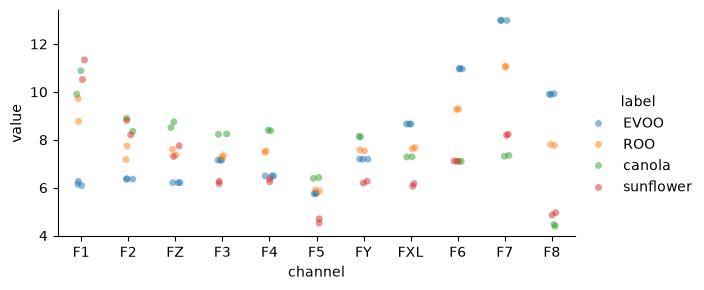

In [7]:
import seaborn
seaborn.catplot(data=tidy_log.reset_index(),
                x='channel',
                order=channel_order,
                hue='label',
                #row='excitation',
                y='value',
                alpha=0.5,
                aspect=2.0, height=3.0,
               )

In [10]:

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier


lda = LinearDiscriminantAnalysis(n_components=2)
d = data.copy()
label_column = 'label'
data_columns = list(set(d.columns) - set([label_column]))
#data_columns = [ 'F6', 'F2' ]
#data_columns = [ 'F7', 'FZ' ]
X_train = data[data_columns]
Y_train = data[label_column]

est = KNeighborsClassifier(1)
est.fit(X_train, Y_train)
est.predict_proba(X_train)

#lda.fit(X_train, Y_train)
#lda.predict_proba(X_train)


array([[1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 0., 0., 1.]])

In [11]:
X_train

channel,F8,F7,F2,F3,FXL,FY,FZ,F6,F4,F5,F1
filename,,,,,,,,,,,
EVOO-channels-907.npy,960.0,8096.0,83.0,142.0,403.0,146.0,74.0,1992.0,90.0,54.0,77.0
EVOO-channels-970.npy,951.0,8101.0,82.0,142.0,406.0,147.0,74.0,2017.0,90.0,54.0,71.0
EVOO-channels-935.npy,970.0,8133.0,82.0,143.0,405.0,146.0,74.0,1991.0,90.0,55.0,68.0
ROO-channels-1239.npy,224.0,2155.0,214.0,161.0,204.0,191.0,194.0,627.0,185.0,60.0,843.0
ROO-channels-1276.npy,217.0,2097.0,145.0,156.0,198.0,186.0,165.0,613.0,179.0,58.0,437.0
canola-channels-1144.npy,22.0,159.0,476.0,304.0,157.0,281.0,431.0,137.0,338.0,86.0,1889.0
canola-channels-1178.npy,21.0,163.0,327.0,300.0,156.0,280.0,365.0,138.0,333.0,84.0,962.0
sunflower-channels-1051.npy,31.0,300.0,448.0,77.0,72.0,77.0,215.0,139.0,83.0,26.0,2587.0
sunflower-channels-1083.npy,29.0,292.0,296.0,72.0,67.0,73.0,158.0,137.0,76.0,23.0,1462.0


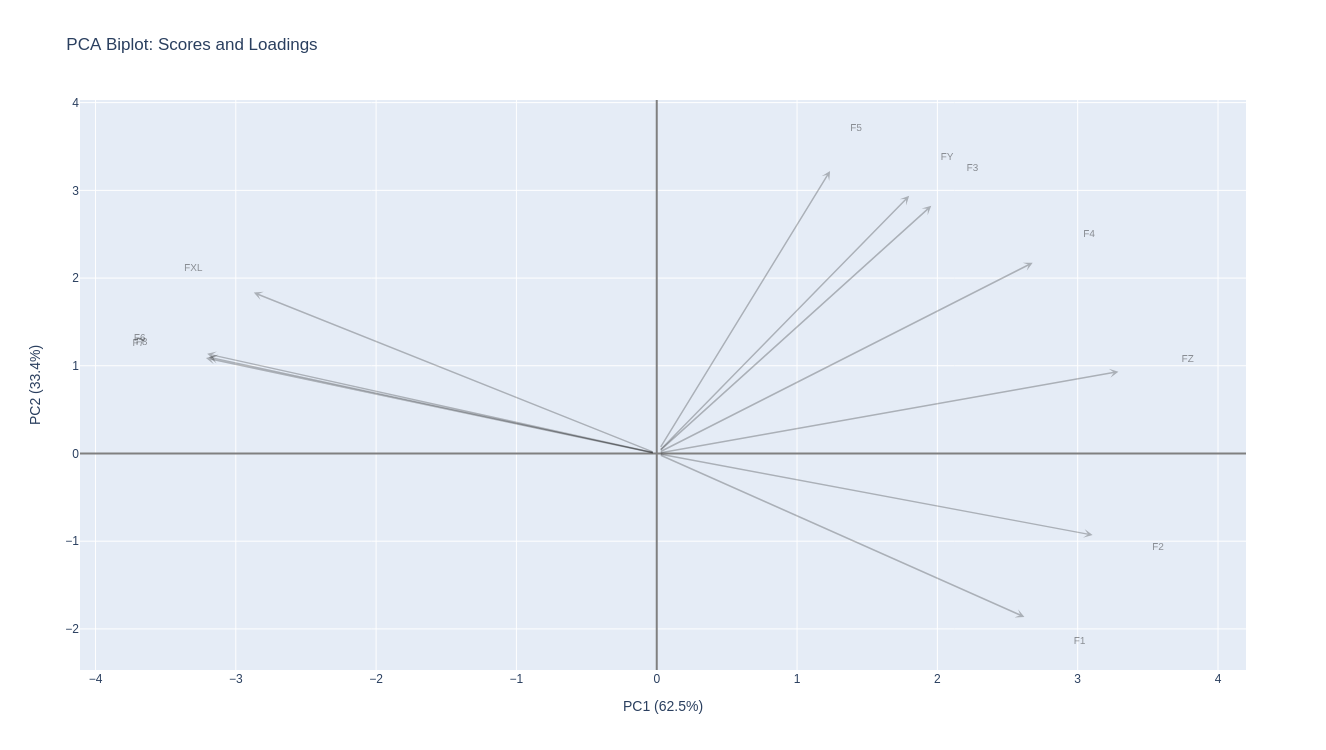

In [28]:

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.express as px
import numpy as np

def plot_pca_biplot(df, group_col='category', arrow_scale=0.8):
    feature_cols = [c for c in df.columns if c != group_col]

    X = StandardScaler().fit_transform(df[feature_cols].values)

    pca = PCA(n_components=2)
    scores = pca.fit_transform(X)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    pc1_var, pc2_var = pca.explained_variance_ratio_ * 100

    scale = np.abs(scores).max() / np.abs(loadings).max() * arrow_scale

    fig = go.Figure()

    colors = df[group_col].astype('category')
    categories = colors.cat.categories
    palette = px.colors.qualitative.Plotly
    if len(categories) > len(palette):
        palette = px.colors.sample_colorscale(
            'turbo', [i / (len(categories) - 1) for i in range(len(categories))]
        )

    for i, cat in enumerate(categories):
        mask = (df[group_col] == cat).values
        fig.add_trace(go.Scatter(
            x=scores[mask, 0], y=scores[mask, 1],
            mode='markers+text',
            text=df.index[mask], textposition='top center',
            marker=dict(size=8, color=palette[i % len(palette)]),
            name=str(cat)
        ))

    for i, feature in enumerate(feature_cols):
        x, y = loadings[i, 0] * scale, loadings[i, 1] * scale
        fig.add_annotation(
            x=x, y=y, ax=0, ay=0,
            xref='x', yref='y', axref='x', ayref='y',
            showarrow=True, arrowhead=3,
            arrowcolor='rgba(0,0,0,0.25)', arrowwidth=1.5
        )
        fig.add_trace(go.Scatter(
            x=[x * 1.15], y=[y * 1.15], mode='text',
            text=[feature], textfont=dict(color='rgba(0,0,0,0.4)', size=10),
            showlegend=False
        ))

    fig.update_layout(
        title='PCA Biplot: Scores and Loadings',
        xaxis_title=f'PC1 ({pc1_var:.1f}%)',
        yaxis_title=f'PC2 ({pc2_var:.1f}%)',
        width=750, height=750,
        xaxis=dict(zeroline=True, zerolinecolor='grey'),
        yaxis=dict(zeroline=True, zerolinecolor='grey'),
        legend_title=group_col
    )

    return fig

dd = data.copy().reset_index()
dd['filename'] = [ 's'+f.split('-')[2].removesuffix('.npy') for f in dd['filename'] ]
dd = dd.set_index('filename')
fig = plot_pca_biplot(dd, group_col='label')
fig.write_html('pca2.html')

In [69]:
def plot_pca_loadings_spectrum(df, freq_map, group_col='category'):
    """
    Plot PC1/PC2 loadings as a spectrum.
    freq_map: dict or Series mapping feature column name (str) -> frequency (numeric)
    """
    feature_cols = [c for c in df.columns if c != group_col]
    freqs = np.array([freq_map[c] for c in feature_cols])

    X = StandardScaler().fit_transform(df[feature_cols].values)
    pca = PCA(n_components=2)
    pca.fit(X)
    loadings = pca.components_.T * np.sqrt(pca.explained_variance_)
    pc1_var, pc2_var = pca.explained_variance_ratio_ * 100

    # sort by frequency for a clean line plot
    order = np.argsort(freqs)
    freqs_sorted = freqs[order]
    loadings_sorted = loadings[order]

    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=freqs_sorted, y=loadings_sorted[:, 0], mode='lines',
        name=f'PC1 ({pc1_var:.1f}%)', line=dict(color='#1f77b4')
    ))
    fig.add_trace(go.Scatter(
        x=freqs_sorted, y=loadings_sorted[:, 1], mode='lines',
        name=f'PC2 ({pc2_var:.1f}%)', line=dict(color='#d62728')
    ))
    fig.add_hline(y=0, line_color='grey', line_width=0.5)

    fig.update_layout(
        title='PCA Loadings Spectrum',
        xaxis_title='Frequency',
        yaxis_title='Loading',
        width=900, height=400
    )
    return fig


dd = data.copy().reset_index()
dd['filename'] = [ 's'+f.split('-')[2].removesuffix('.npy') for f in dd['filename'] ]
dd = dd.set_index('filename')
fig = plot_pca_loadings_spectrum(dd, freq_map=channel_info.peak_wavelength, group_col='label')
fig.write_html('pca_loading_spectrum.html')

In [67]:
def hex_to_rgba(hex_color, alpha=0.15):
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r},{g},{b},{alpha})'


from sklearn.decomposition import PCA, SparsePCA

def plot_pca_loadings_spectrum(df, freq_map, group_col='category',
                                flip_sign=True, method='pca', alpha=1.0):
    """
    method: 'pca' or 'sparse' (SparsePCA, alpha controls sparsity strength)
    """
    feature_cols = [c for c in df.columns if c != group_col]
    freqs = np.array([freq_map[c] for c in feature_cols])

    X = StandardScaler().fit_transform(df[feature_cols].values)

    if method == 'sparse':
        model = SparsePCA(n_components=2, alpha=alpha, random_state=0)
        model.fit(X)
        loadings = model.components_.T
        # SparsePCA has no explained_variance_ratio_; compute manually
        scores = model.transform(X)
        total_var = np.var(X, axis=0).sum()
        var_explained = np.var(scores, axis=0) / total_var * 100
        pc1_var, pc2_var = var_explained[0], var_explained[1]
    else:
        model = PCA(n_components=2)
        model.fit(X)
        loadings = model.components_.T * np.sqrt(model.explained_variance_)
        pc1_var, pc2_var = model.explained_variance_ratio_ * 100

    if flip_sign:
        for i in range(loadings.shape[1]):
            if loadings[np.argmax(np.abs(loadings[:, i])), i] < 0:
                loadings[:, i] *= -1

    order = np.argsort(freqs)
    freqs_sorted = freqs[order]
    loadings_sorted = loadings[order]

    fig = go.Figure()
    colors = {'PC1': '#1f77b4', 'PC2': '#d62728'}
    for i, (name, var) in enumerate([('PC1', pc1_var), ('PC2', pc2_var)]):
        c = colors[name]
        fig.add_trace(go.Scatter(
            x=freqs_sorted, y=loadings_sorted[:, i], mode='lines',
            name=f'{name} ({var:.1f}%)', line=dict(color=c),
            fill='tozeroy', fillcolor=hex_to_rgba(c, 0.15)
        ))

    fig.add_hline(y=0, line_color='grey', line_width=0.5)
    fig.update_layout(
        title=f'{"Sparse " if method=="sparse" else ""}PCA Loadings Spectrum (sign-normalized)',
        xaxis_title='Frequency', yaxis_title='Loading',
        width=900, height=400
    )
    return fig

dd = data.copy().reset_index()
dd['filename'] = [ 's'+f.split('-')[2].removesuffix('.npy') for f in dd['filename'] ]
dd = dd.set_index('filename')
fig = plot_pca_loadings_spectrum(dd, freq_map=channel_info.peak_wavelength, group_col='label', method='sparse')
fig.write_html('pca_loading_spectrum2.html')

In [68]:
from sklearn.decomposition import PCA, SparsePCA
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
import plotly.express as px
import numpy as np


def compute_pca(df, group_col='category', method='pca', alpha=1.0):
    """
    Fit PCA (or SparsePCA) on df and return a dict of shared results
    used by both plotting functions.
    """
    feature_cols = [c for c in df.columns if c != group_col]
    X = StandardScaler().fit_transform(df[feature_cols].values)

    if method == 'sparse':
        model = SparsePCA(n_components=3, alpha=alpha, random_state=0)
        scores = model.fit_transform(X)
        loadings = model.components_.T
        total_var = np.var(X, axis=0).sum()
        var_explained = np.var(scores, axis=0) / total_var * 100
    else:
        model = PCA(n_components=2)
        scores = model.fit_transform(X)
        loadings = model.components_.T * np.sqrt(model.explained_variance_)
        var_explained = model.explained_variance_ratio_ * 100

    return {
        'model': model,
        'method': method,
        'scores': scores,
        'loadings': loadings,
        'var_explained': var_explained,   # [pc1_var, pc2_var]
        'feature_cols': feature_cols,
        'index': df.index,
        'groups': df[group_col],
    }


def hex_to_rgba(hex_color, alpha=0.15):
    hex_color = hex_color.lstrip('#')
    r, g, b = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))
    return f'rgba({r},{g},{b},{alpha})'


def plot_pca_biplot(pca_result, arrow_scale=0.8):
    scores = pca_result['scores']
    loadings = pca_result['loadings']
    pc1_var, pc2_var, _ = pca_result['var_explained']
    feature_cols = pca_result['feature_cols']
    index = pca_result['index']
    groups = pca_result['groups']

    scale = np.abs(scores).max() / np.abs(loadings).max() * arrow_scale

    fig = go.Figure()

    categories = groups.astype('category').cat.categories
    palette = px.colors.qualitative.Plotly
    if len(categories) > len(palette):
        palette = px.colors.sample_colorscale(
            'turbo', [i / (len(categories) - 1) for i in range(len(categories))]
        )

    for i, cat in enumerate(categories):
        mask = (groups == cat).values
        fig.add_trace(go.Scatter(
            x=scores[mask, 0], y=scores[mask, 1],
            mode='markers+text',
            text=index[mask], textposition='top center',
            marker=dict(size=8, color=palette[i % len(palette)]),
            name=str(cat)
        ))

    for i, feature in enumerate(feature_cols):
        x, y = loadings[i, 0] * scale, loadings[i, 1] * scale
        fig.add_annotation(
            x=x, y=y, ax=0, ay=0,
            xref='x', yref='y', axref='x', ayref='y',
            showarrow=True, arrowhead=3,
            arrowcolor='rgba(0,0,0,0.25)', arrowwidth=1.5
        )
        fig.add_trace(go.Scatter(
            x=[x * 1.15], y=[y * 1.15], mode='text',
            text=[feature], textfont=dict(color='rgba(0,0,0,0.4)', size=10),
            showlegend=False
        ))

    fig.update_layout(
        title='PCA Biplot: Scores and Loadings',
        xaxis_title=f'PC1 ({pc1_var:.1f}%)',
        yaxis_title=f'PC2 ({pc2_var:.1f}%)',
        width=750, height=750,
        xaxis=dict(zeroline=True, zerolinecolor='grey'),
        yaxis=dict(zeroline=True, zerolinecolor='grey'),
        legend_title=groups.name
    )
    return fig


def plot_pca_loadings_spectrum(pca_result, freq_map, flip_sign=True):
    loadings = pca_result['loadings'].copy()
    pc1_var, pc2_var, _ = pca_result['var_explained']
    feature_cols = pca_result['feature_cols']
    method = pca_result['method']

    freqs = np.array([freq_map[c] for c in feature_cols])

    if flip_sign:
        for i in range(loadings.shape[1]):
            if loadings[np.argmax(np.abs(loadings[:, i])), i] < 0:
                loadings[:, i] *= -1

    order = np.argsort(freqs)
    freqs_sorted = freqs[order]
    loadings_sorted = loadings[order]

    fig = go.Figure()
    colors = {'PC1': '#1f77b4', 'PC2': '#d62728'}
    for i, (name, var) in enumerate([('PC1', pc1_var), ('PC2', pc2_var)]):
        c = colors[name]
        fig.add_trace(go.Scatter(
            x=freqs_sorted, y=loadings_sorted[:, i], mode='lines',
            name=f'{name} ({var:.1f}%)', line=dict(color=c),
            fill='tozeroy', fillcolor=hex_to_rgba(c, 0.15)
        ))

    fig.add_hline(y=0, line_color='grey', line_width=0.5)
    fig.update_layout(
        title=f'{"Sparse " if method == "sparse" else ""}PCA Loadings Spectrum (sign-normalized)',
        xaxis_title='Frequency', yaxis_title='Loading',
        width=900, height=400
    )
    return fig


dd = data.copy().reset_index()
dd['filename'] = [ 's'+f.split('-')[2].removesuffix('.npy') for f in dd['filename'] ]
dd = dd.set_index('filename')

pca_result = compute_pca(dd, group_col='label', method='sparse', alpha=2.9)  # or method='sparse', alpha=2.0

print(pca_result['var_explained'])
fig1 = plot_pca_biplot(pca_result)
fig2 = plot_pca_loadings_spectrum(pca_result, freq_map=channel_info.peak_wavelength)

fig1.write_html('pca2.html')
fig2.write_html('pca_loading_spectrum2.html')

[31.433062 25.476944  8.911781]
